In [1]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

# Statistic summary

In [2]:
PROJECT_ID = "gannett-datascience"
TABLE_ID = "gannett-datascience.test_results_zone.ss_test_result_v3-2"

NUMERIC_FIELDS = [
    "frequency",
    "breadth",
    "tenure",
    "tt_cost"
]
SEGMENT_FIELDS = [
    "src_risk_tier",
    "cohort",
    "Treatment",
    "contact_channel",
    "status",
    "contact_timing",
    "repeatedly_called"
]
IDS = [
    "billing_account",
    "id_subscrip",
    "email_date"
]

client = bigquery.Client(project=PROJECT_ID)

/Users/YKang1/PycharmProjects/stop_save_pChurn/.venv/lib/python3.13/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


In [3]:
query = f"""
SELECT
  {", ".join(NUMERIC_FIELDS + SEGMENT_FIELDS + IDS)}
FROM `{TABLE_ID}`
where email_date < '2026-05-01'
"""
df = client.query(query).to_dataframe()
df.head()

/Users/YKang1/PycharmProjects/stop_save_pChurn/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,frequency,breadth,tenure,tt_cost,src_risk_tier,cohort,Treatment,contact_channel,status,contact_timing,repeatedly_called,billing_account,id_subscrip,email_date
0,0,0,510,169.83,None,Two-Offer Cohort,Midpoint,No Action yet,No Action yet,Contact On/After Pricing,0,g-s9207286766,76632424,2026-04-03
1,61,13,1302,867.57,2. Med-Low,Three-Offer Cohort,Midpoint,No Action yet,No Action yet,Contact On/After Pricing,0,mc-s000366007,73998657,2026-04-03
2,76,9,1301,216.40,1. Low,Three-Offer Cohort,Midpoint,Online Cancel Flow,stoped,Contact Before Pricing,0,mc-s000608506,74038232,2026-04-03
3,78,11,1719,472.72,None,Two-Offer Cohort,Midpoint,No Action yet,No Action yet,Contact On/After Pricing,0,mn-s000384159,65819195,2026-04-03
4,90,10,1424,474.19,1. Low,Three-Offer Cohort,Midpoint,Called-In Cancel Flow,stoped,Contact Before Pricing,0,mc-s000604935,73466660,2026-04-03


In [4]:
for col in NUMERIC_FIELDS:
    df[col] = df[col].astype('float64')

print("Shape:", df.shape)
df.info()

Shape: (8964, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8964 entries, 0 to 8963
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   frequency          8955 non-null   float64
 1   breadth            8955 non-null   float64
 2   tenure             8955 non-null   float64
 3   tt_cost            8955 non-null   float64
 4   src_risk_tier      5393 non-null   object 
 5   cohort             8964 non-null   object 
 6   Treatment          8964 non-null   object 
 7   contact_channel    8964 non-null   object 
 8   status             8964 non-null   object 
 9   contact_timing     8964 non-null   object 
 10  repeatedly_called  8964 non-null   Int64  
 11  billing_account    8964 non-null   object 
 12  id_subscrip        8964 non-null   Int64  
 13  email_date         8964 non-null   dbdate 
dtypes: Int64(2), dbdate(1), float64(4), object(7)
memory usage: 998.1+ KB


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
frequency,"8,955.00",NaN,NaN,NaN,40.29,35.39,0.00,3.00,33.00,79.00,91.00
breadth,"8,955.00",NaN,NaN,NaN,4.38,4.25,0.00,0.00,4.00,7.00,21.00
tenure,"8,955.00",NaN,NaN,NaN,"1,404.66",835.21,208.00,"1,056.00","1,363.00","1,649.00","18,722.00"
tt_cost,"8,955.00",NaN,NaN,NaN,562.51,416.32,0.00,361.97,501.08,685.81,"8,050.46"
src_risk_tier,5393,5,1. Low,2377,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cohort,8964,2,Three-Offer Cohort,5393,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Treatment,8964,3,Control,3612,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact_channel,8964,5,No Action yet,7429,NaN,NaN,NaN,NaN,NaN,NaN,NaN
status,8964,3,No Action yet,7429,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact_timing,8964,2,Contact On/After Pricing,7974,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
quality_checks = []

for col in NUMERIC_FIELDS:
    quality_checks.append({
        "field": col,
        "row_count": len(df),
        "null_count": df[col].isna().sum(),
        "null_pct": df[col].isna().mean() * 100,
        "zero_count": (df[col] == 0).sum(),
        "negative_count": (df[col] < 0).sum(),
        "min": df[col].min(),
        "max": df[col].max(),
        "mean": df[col].mean(),
        "median": df[col].median()
    })

quality_df = pd.DataFrame(quality_checks)
quality_df

,field,row_count,null_count,null_pct,zero_count,negative_count,min,max,mean,median
0,frequency,8964,9,0.10,1676,0,0.00,91.00,40.29,33.00
1,breadth,8964,9,0.10,2572,0,0.00,21.00,4.38,4.00
2,tenure,8964,9,0.10,0,0,208.00,"18,722.00","1,404.66","1,363.00"
3,tt_cost,8964,9,0.10,10,0,0.00,"8,050.46",562.51,501.08


In [7]:
percentiles = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]

percentile_summary = df[NUMERIC_FIELDS].quantile(percentiles).T
percentile_summary.columns = [f"p{int(p * 100):02d}" for p in percentiles]

summary_stats = df[NUMERIC_FIELDS].agg(["count", "mean", "std", "min", "max"]).T

distribution_summary = summary_stats.join(percentile_summary)
distribution_summary

,count,mean,std,min,max,p01,p05,p10,p25,p50,p75,p90,p95,p99
frequency,"8,955.00",40.29,35.39,0.00,91.00,0.00,0.00,0.00,3.00,33.00,79.00,90.00,91.00,91.00
breadth,"8,955.00",4.38,4.25,0.00,21.00,0.00,0.00,0.00,0.00,4.00,7.00,10.00,12.00,16.00
tenure,"8,955.00","1,404.66",835.21,208.00,"18,722.00",324.00,339.00,506.00,"1,056.00","1,363.00","1,649.00","2,150.00","2,506.60","3,445.84"
tt_cost,"8,955.00",562.51,416.32,0.00,"8,050.46",107.89,113.22,168.07,361.97,501.08,685.81,919.75,"1,252.46","1,765.65"


# Vis - Histogram

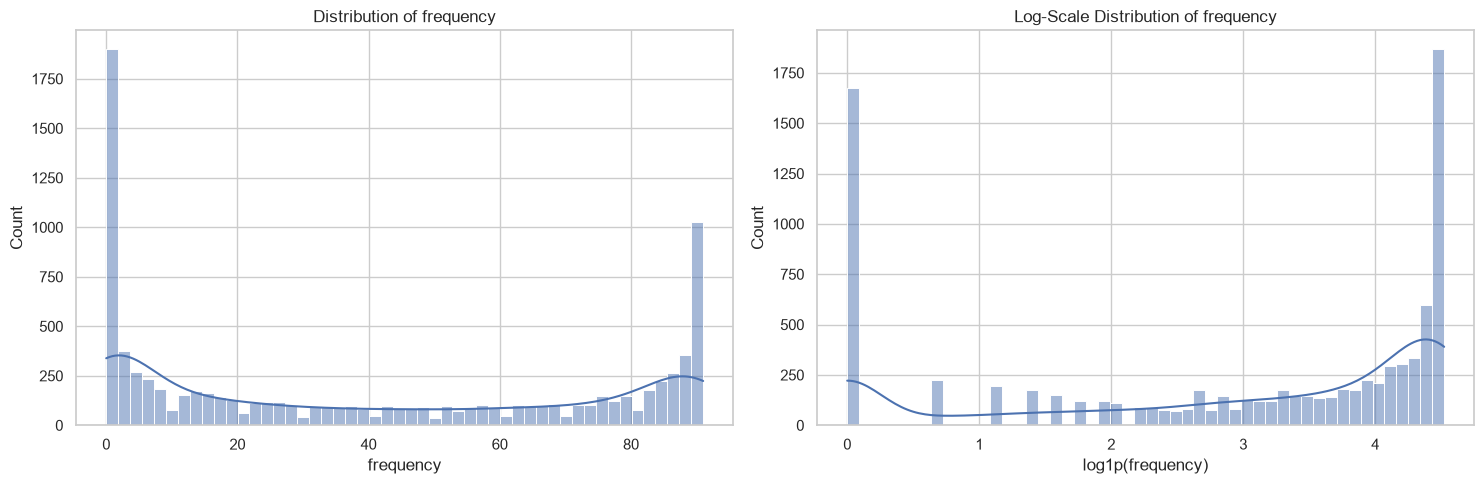

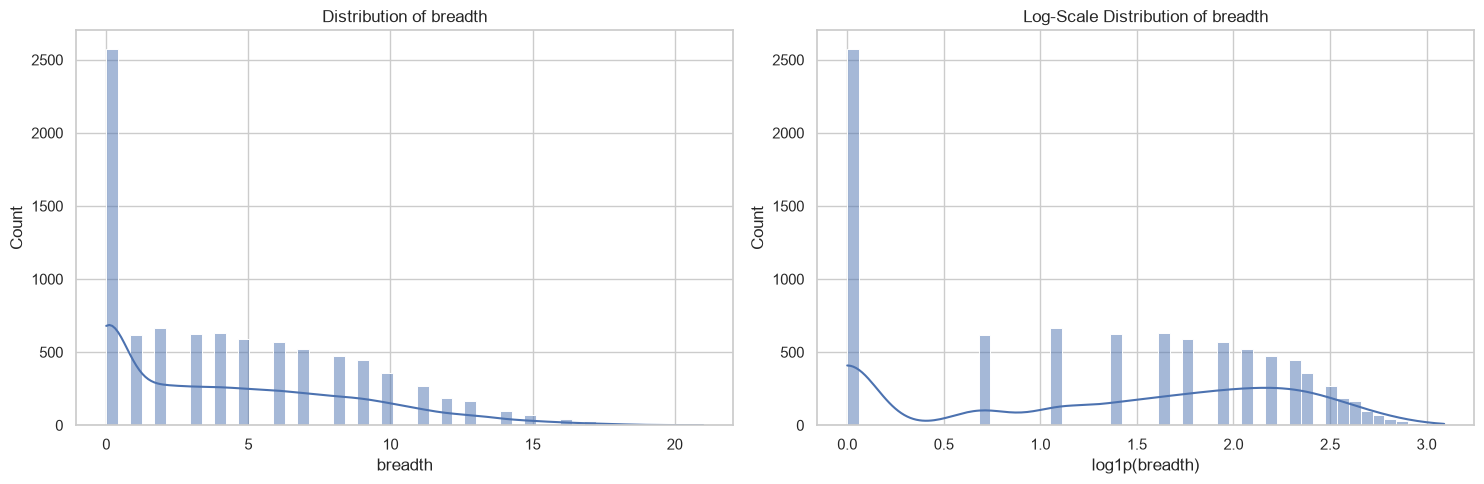

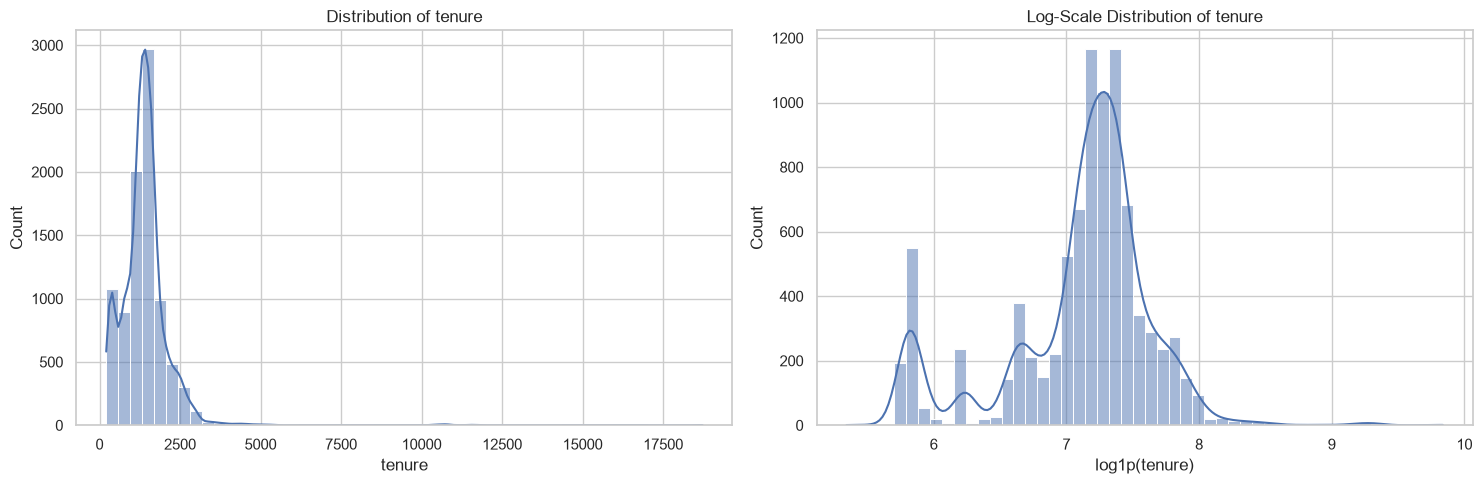

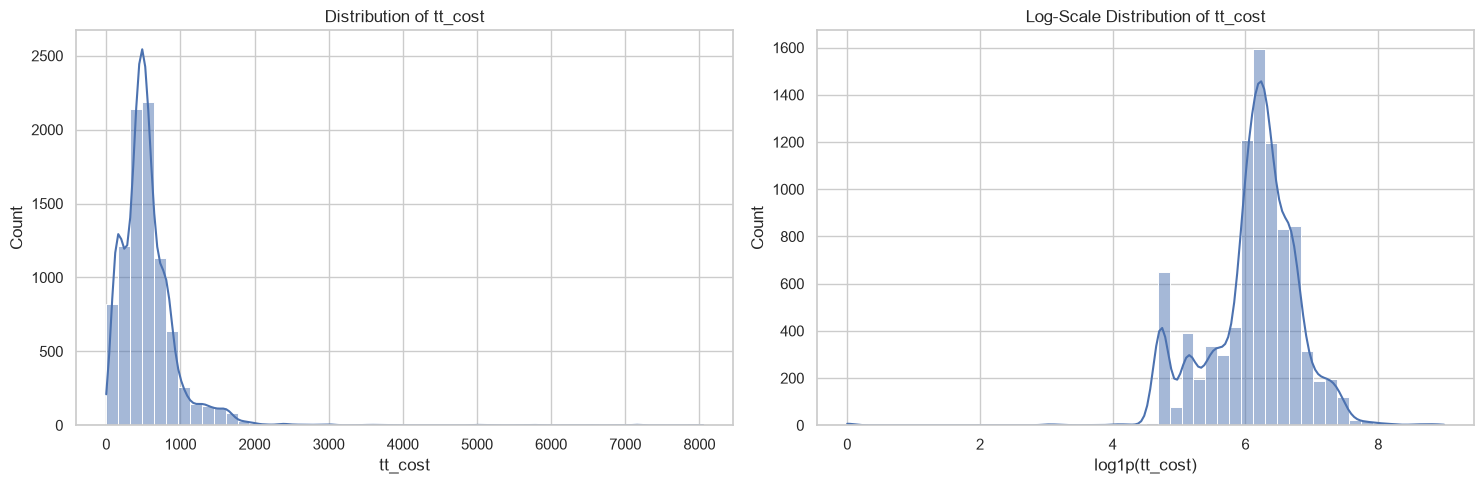

In [8]:
for col in NUMERIC_FIELDS:
    values = df[col].dropna()

    non_negative_values = values[values >= 0]

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Original histogram
    sns.histplot(
        values,
        bins=50,
        kde=True,
        ax=axes[0]
    )
    axes[0].set_title(f"Distribution of {col}")
    axes[0].set_xlabel(col)
    axes[0].set_ylabel("Count")

    # Log-scale histogram
    sns.histplot(
        np.log1p(non_negative_values),
        bins=50,
        kde=True,
        ax=axes[1]
    )
    axes[1].set_title(f"Log-Scale Distribution of {col}")
    axes[1].set_xlabel(f"log1p({col})")
    axes[1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()

# Vis - Boxplot

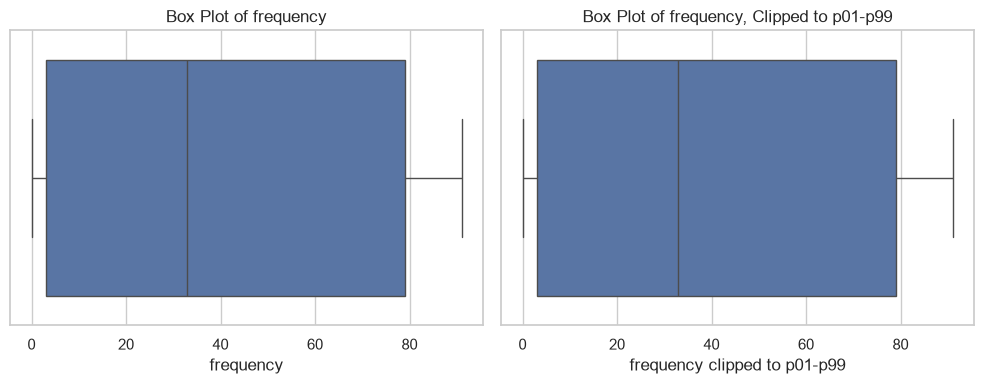

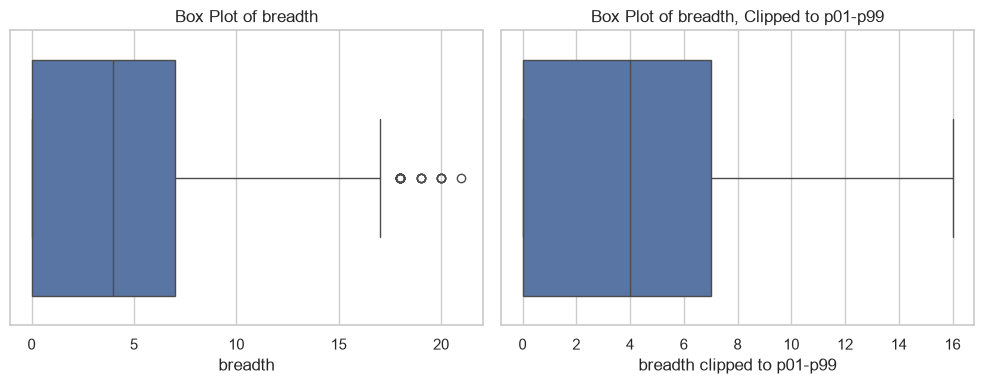

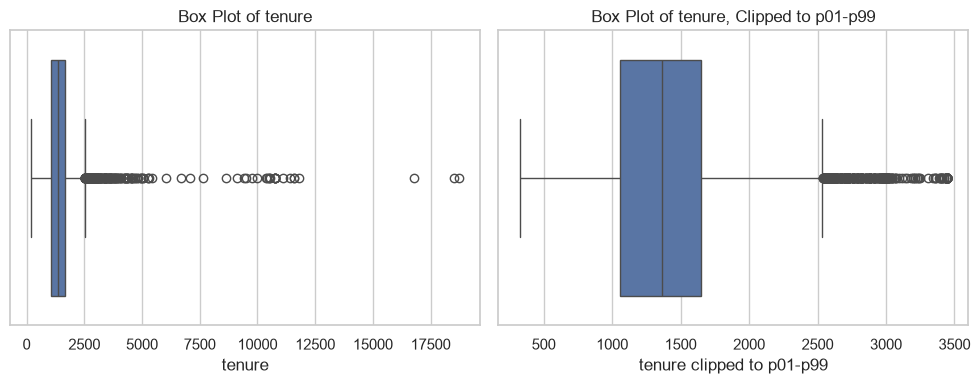

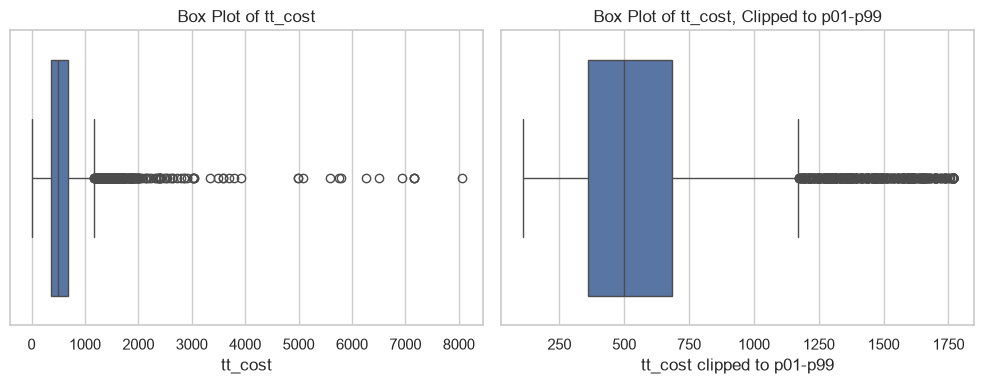

In [9]:

for col in NUMERIC_FIELDS:
    values = df[col].dropna()

    lower = values.quantile(0.01)
    upper = values.quantile(0.99)
    clipped_values = values.clip(lower, upper)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Full box plot
    sns.boxplot(
        x=values,
        ax=axes[0]
    )
    axes[0].set_title(f"Box Plot of {col}")
    axes[0].set_xlabel(col)

    # Visually clipped box plot
    sns.boxplot(
        x=clipped_values,
        ax=axes[1]
    )
    axes[1].set_title(f"Box Plot of {col}, Clipped to p01-p99")
    axes[1].set_xlabel(f"{col} clipped to p01-p99")

    plt.tight_layout()
    plt.show()

In [10]:
outlier_summary = []

for col in NUMERIC_FIELDS:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()

    outlier_summary.append({
        "field": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_pct": outlier_count / len(df) * 100
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,field,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
0,frequency,3.00,79.00,76.00,-111.00,193.00,0,0.00
1,breadth,0.00,7.00,7.00,-10.50,17.50,26,0.29
2,tenure,"1,056.00","1,649.00",593.00,166.50,"2,538.50",417,4.65
3,tt_cost,361.97,685.81,323.84,-123.79,"1,171.58",516,5.76


# Vis - Correlation, Pairplot, Scatterplot

In [11]:
corr_matrix = df[NUMERIC_FIELDS].corr()
corr_matrix

,frequency,breadth,tenure,tt_cost
frequency,1.00,0.67,0.10,0.05
breadth,0.67,1.00,0.09,0.04
tenure,0.10,0.09,1.00,0.81
tt_cost,0.05,0.04,0.81,1.00


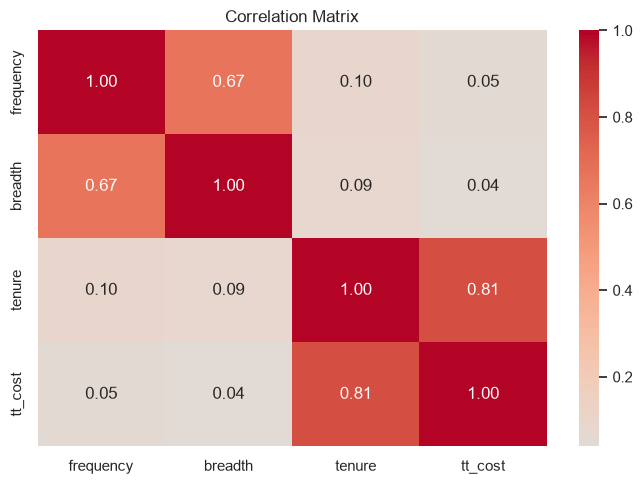

In [12]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [13]:
# sample_df = df[NUMERIC_FIELDS].dropna().sample(
#     min(5000, len(df.dropna())),
#     random_state=42
# )

# sns.pairplot(sample_df)
# plt.show()

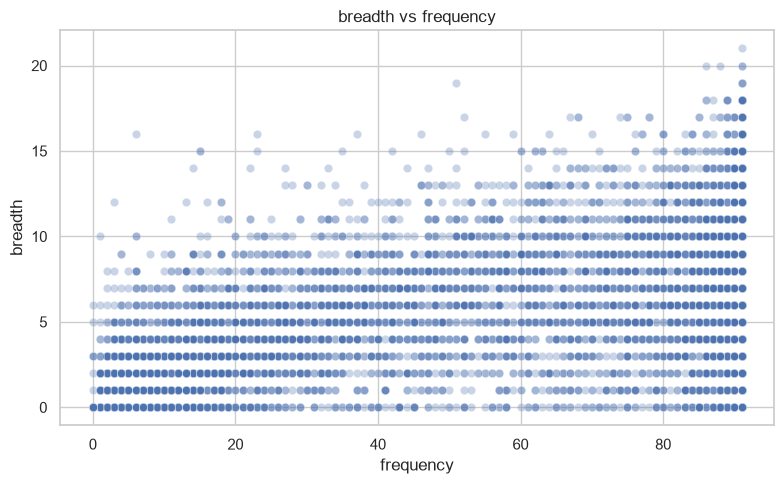

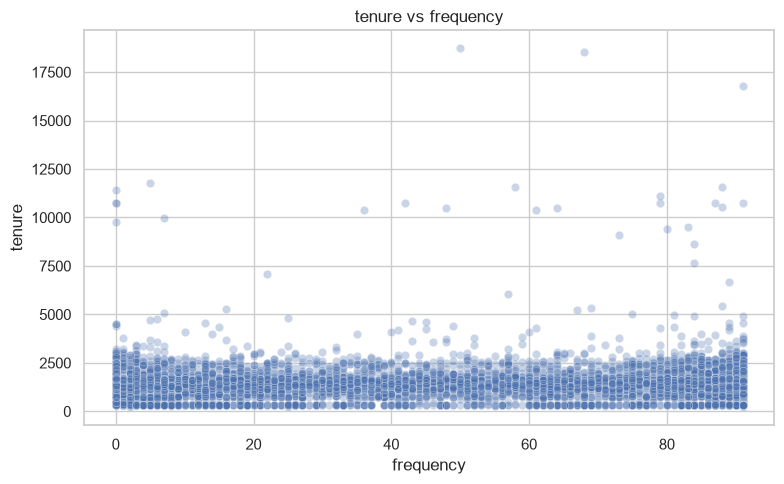

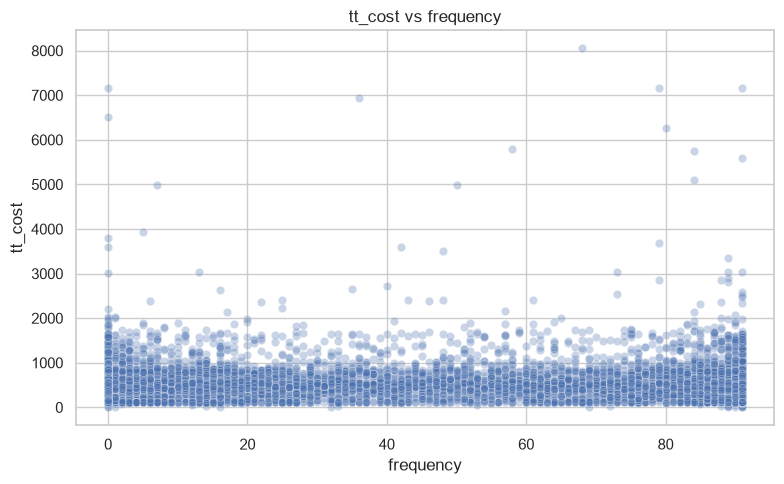

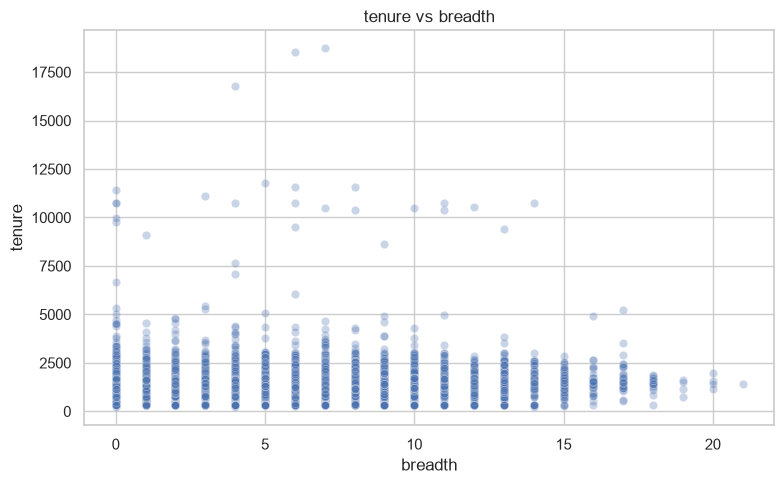

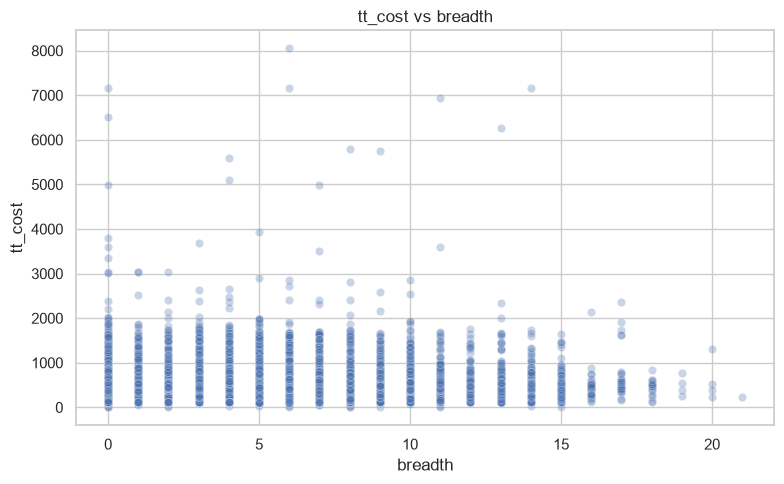

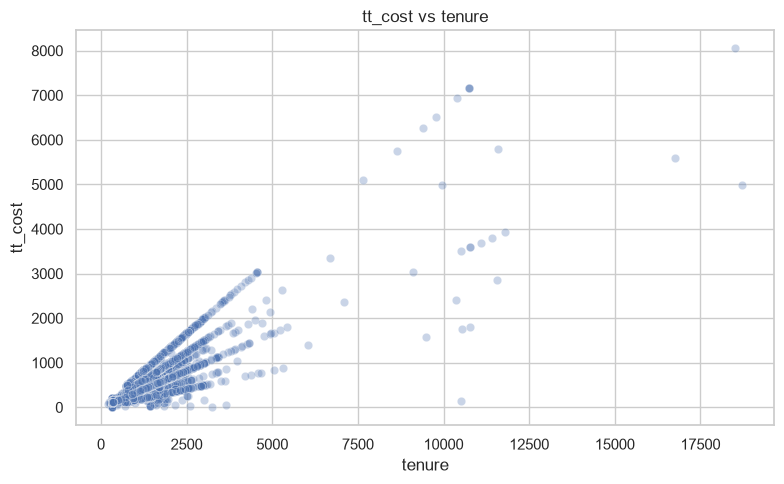

In [14]:
pairs = [
    ("frequency", "breadth"),
    ("frequency", "tenure"),
    ("frequency", "tt_cost"),
    ("breadth", "tenure"),
    ("breadth", "tt_cost"),
    ("tenure", "tt_cost")
]

for x_col, y_col in pairs:
    if x_col in df.columns and y_col in df.columns:
        plt.figure(figsize=(8, 5))
        sns.scatterplot(
            data=df.sample(min(10000, len(df)), random_state=42),
            x=x_col,
            y=y_col,
            alpha=0.3
        )
        plt.title(f"{y_col} vs {x_col}")
        plt.xlabel(x_col)
        plt.ylabel(y_col)
        plt.tight_layout()
        plt.show()

# Vis - Custom bucket

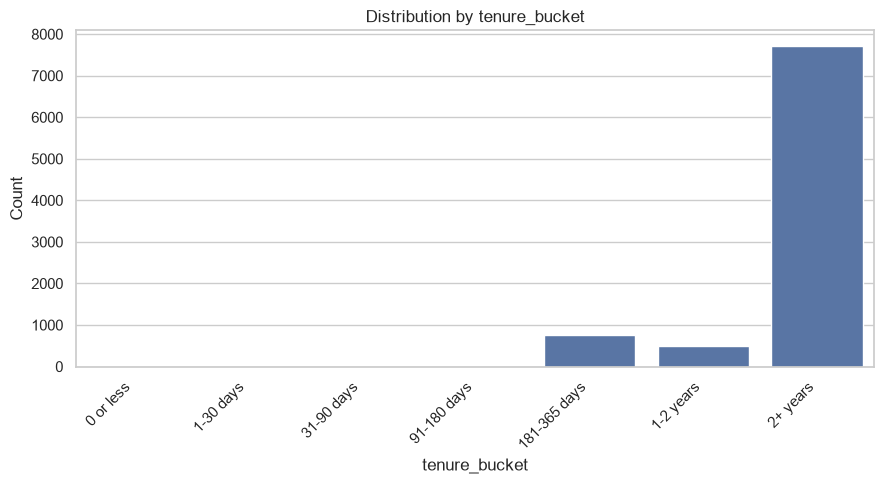

,tenure_bucket,count
0,2+ years,7703
1,181-365 days,758
2,1-2 years,494
3,NaN,9
4,0 or less,0
5,1-30 days,0
6,31-90 days,0
7,91-180 days,0


In [15]:
df["tenure_bucket"] = pd.cut(
    df["tenure"],
    bins=[-np.inf, 0, 30, 90, 180, 365, 730, np.inf],
    labels=[
        "0 or less",
        "1-30 days",
        "31-90 days",
        "91-180 days",
        "181-365 days",
        "1-2 years",
        "2+ years"
    ]
)

bucket_cols = ["tenure_bucket"] #, "cost_bucket", "frequency_bucket"]

for col in bucket_cols:
    bucket_counts = (
        df[col]
        .value_counts(dropna=False)
        .reset_index()
    )
    bucket_counts.columns = [col, "count"]

    plt.figure(figsize=(9, 5))
    sns.barplot(
        data=bucket_counts,
        x=col,
        y="count"
    )
    plt.title(f"Distribution by {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    display(bucket_counts)

# Vis - Boxplots of Segments

In [16]:
for segment in SEGMENT_FIELDS:
    if segment in df.columns:
        print(f"\nSegment summary by {segment}")

        segment_summary = (
            df.groupby(segment)
            .agg(
                users=("billing_account", "count"),
                avg_frequency=("frequency", "mean"),
                median_frequency=("frequency", "median"),
                p90_frequency=("frequency", lambda x: x.quantile(0.90)),
                avg_breadth=("breadth", "mean"),
                median_breadth=("breadth", "median"),
                p90_breadth=("breadth", lambda x: x.quantile(0.90)),
                avg_tenure=("tenure", "mean"),
                median_tenure=("tenure", "median"),
                avg_total_cost=("tt_cost", "mean"),
                median_total_cost=("tt_cost", "median"),
                p90_total_cost=("tt_cost", lambda x: x.quantile(0.90)),

            )
            .reset_index()
            .sort_values("users", ascending=False)
        )

        display(segment_summary)


Segment summary by src_risk_tier


,src_risk_tier,users,avg_frequency,median_frequency,p90_frequency,avg_breadth,median_breadth,p90_breadth,avg_tenure,median_tenure,avg_total_cost,median_total_cost,p90_total_cost
0,1. Low,2377,71.70,84.00,91.00,6.73,7.00,12.00,"1,582.67","1,509.00",599.99,507.16,"1,068.53"
2,3. Medium,1368,10.38,3.00,34.00,1.75,0.00,6.00,"1,273.88","1,328.00",581.37,553.45,886.89
1,2. Med-Low,1205,40.11,40.00,71.60,5.04,5.00,10.00,"1,520.40","1,454.00",693.06,614.38,"1,273.27"
3,4. Med-High,423,7.20,3.00,20.00,1.59,0.00,5.00,906.88,865.00,383.45,382.25,529.05
4,5. High,20,10.60,1.00,23.40,2.75,1.50,8.20,"1,054.10","1,241.00",396.53,432.57,679.03



Segment summary by cohort


,cohort,users,avg_frequency,median_frequency,p90_frequency,avg_breadth,median_breadth,p90_breadth,avg_tenure,median_tenure,avg_total_cost,median_total_cost,p90_total_cost
0,Three-Offer Cohort,5393,43.80,42.00,90.00,4.67,4.00,11.00,"1,435.46","1,362.00",598.32,517.48,"1,024.91"
1,Two-Offer Cohort,3571,34.99,21.00,89.00,3.95,3.00,10.00,"1,358.01","1,363.00",508.28,472.86,811.46



Segment summary by Treatment


...

,status,users,avg_frequency,median_frequency,p90_frequency,avg_breadth,median_breadth,p90_breadth,avg_tenure,median_tenure,avg_total_cost,median_total_cost,p90_total_cost
0,No Action yet,7429,39.15,30.00,90.00,4.25,3.00,10.00,"1,384.81","1,359.00",574.59,503.99,957.97
2,stoped,942,39.35,33.00,89.00,4.64,4.00,11.00,"1,476.51","1,421.00",526.75,483.85,839.16
1,saved,593,56.18,66.00,91.00,5.68,5.00,11.00,"1,539.49","1,454.00",467.62,428.00,787.88



Segment summary by contact_timing


,contact_timing,users,avg_frequency,median_frequency,p90_frequency,avg_breadth,median_breadth,p90_breadth,avg_tenure,median_tenure,avg_total_cost,median_total_cost,p90_total_cost
1,Contact On/After Pricing,7974,39.61,31.00,90.00,4.29,3.00,10.00,"1,389.53","1,360.00",568.68,502.83,938.37
0,Contact Before Pricing,990,45.82,46.00,90.00,5.12,5.00,11.00,"1,526.49","1,451.00",512.77,463.87,847.16



Segment summary by repeatedly_called


,repeatedly_called,users,avg_frequency,median_frequency,p90_frequency,avg_breadth,median_breadth,p90_breadth,avg_tenure,median_tenure,avg_total_cost,median_total_cost,p90_total_cost
0,0,8953,40.26,33.00,90.00,4.38,3.00,10.00,"1,404.29","1,363.00",562.65,501.08,919.75
1,1,11,71.90,89.00,91.00,6.70,5.50,10.40,"1,730.10","1,432.00",432.02,427.23,764.62


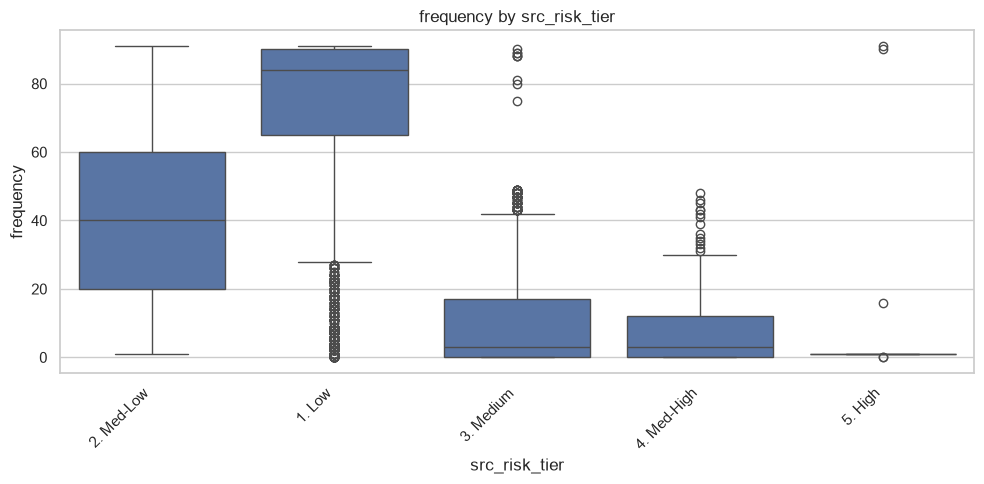

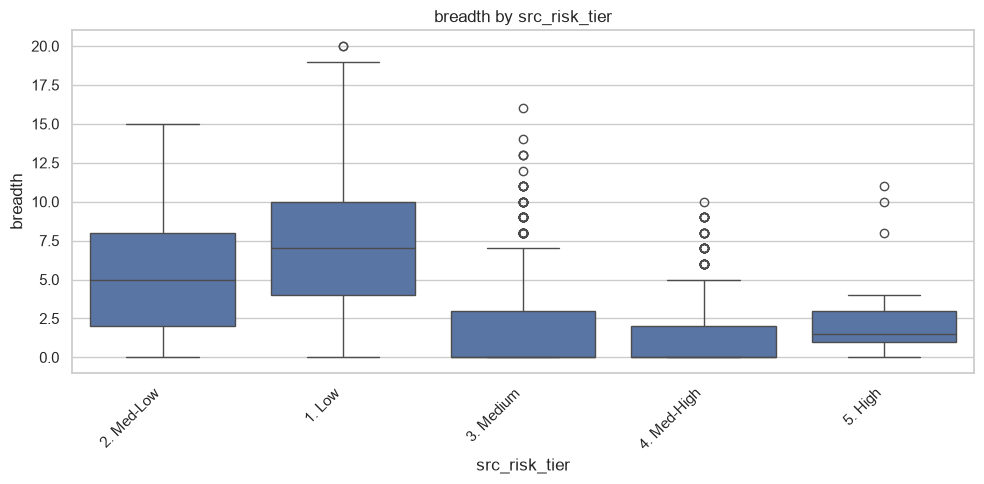

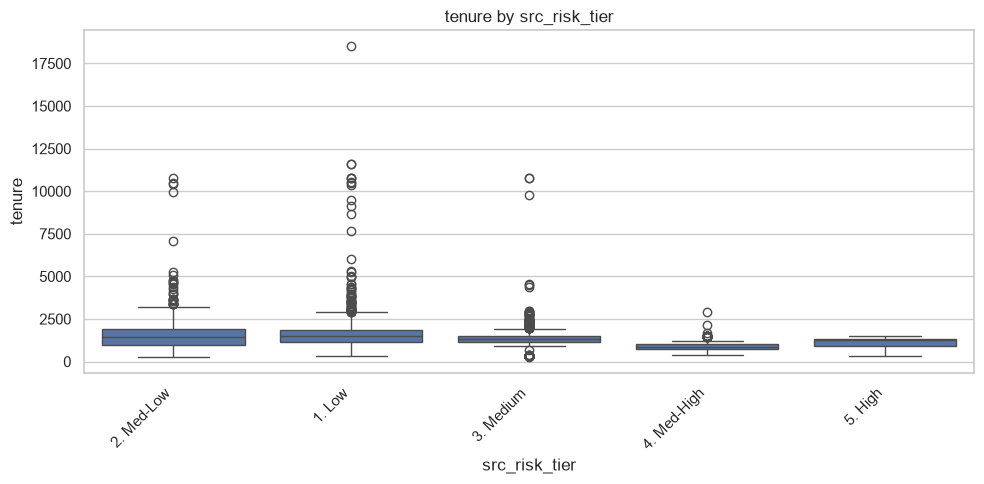

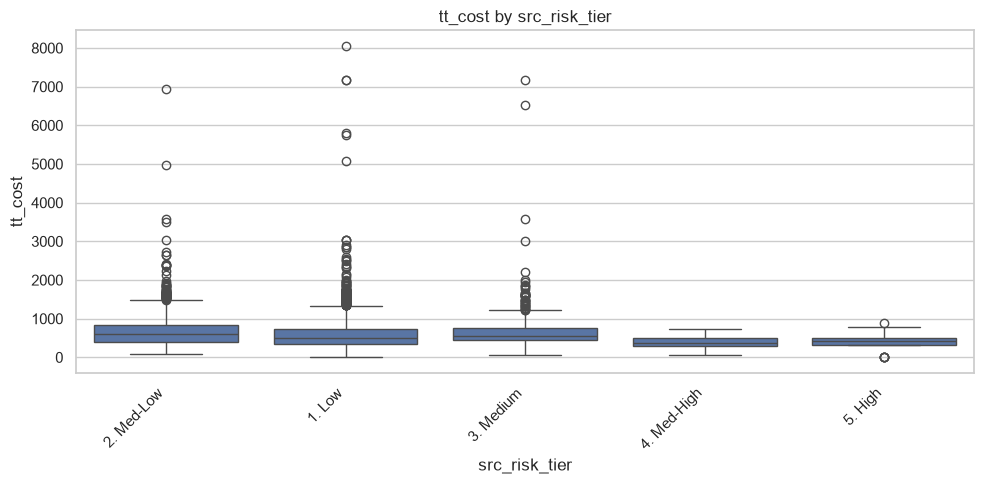

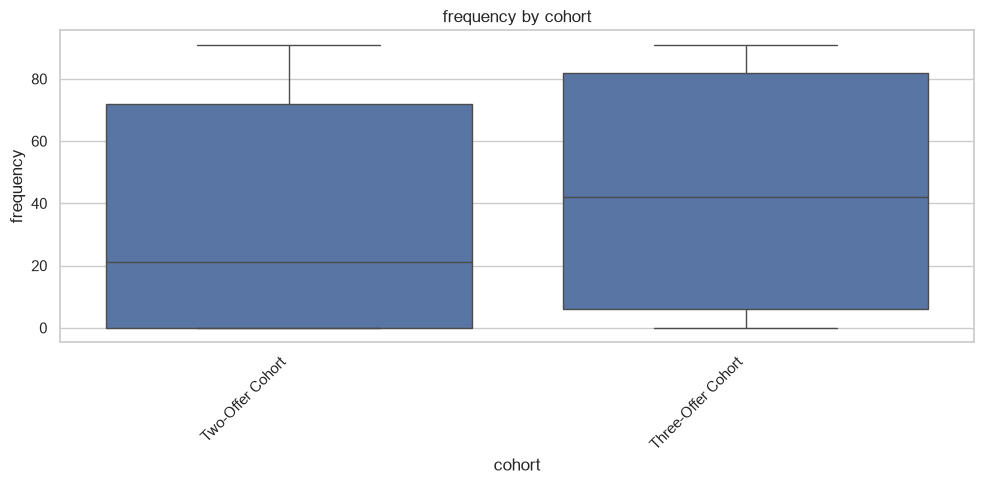

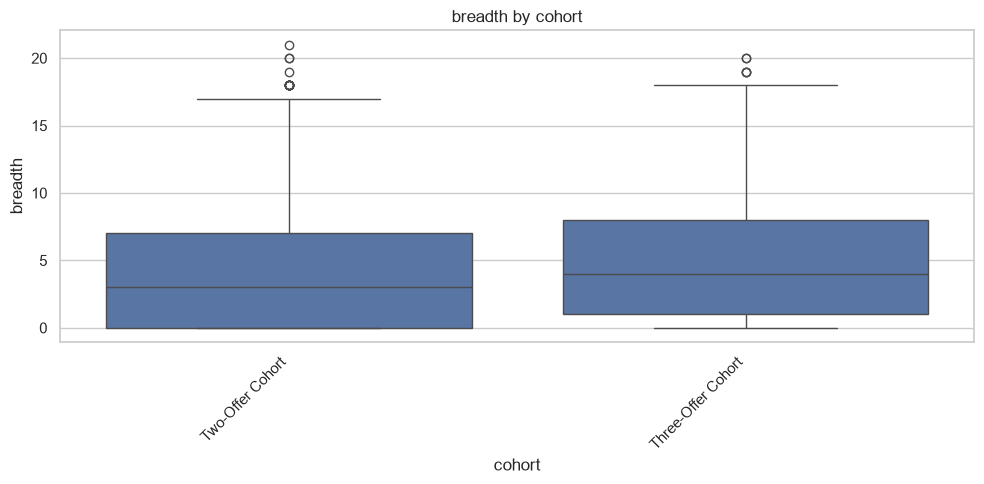

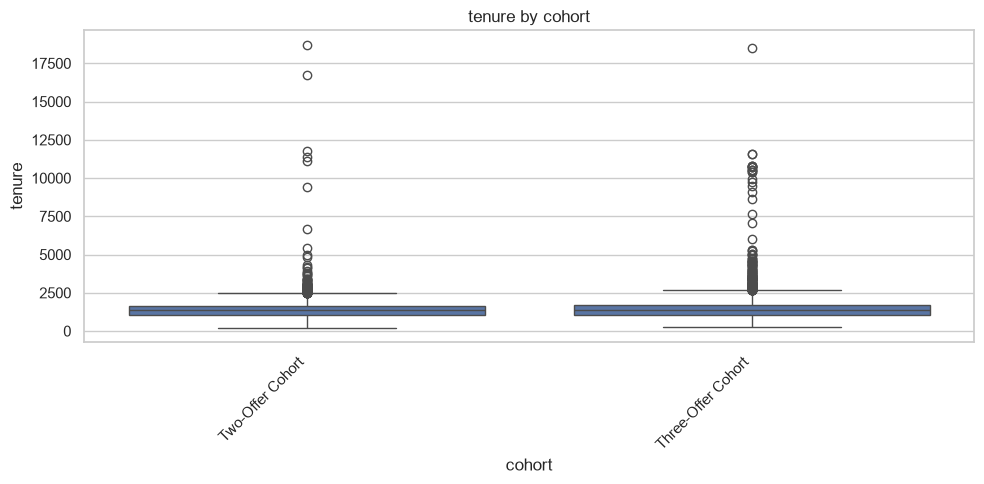

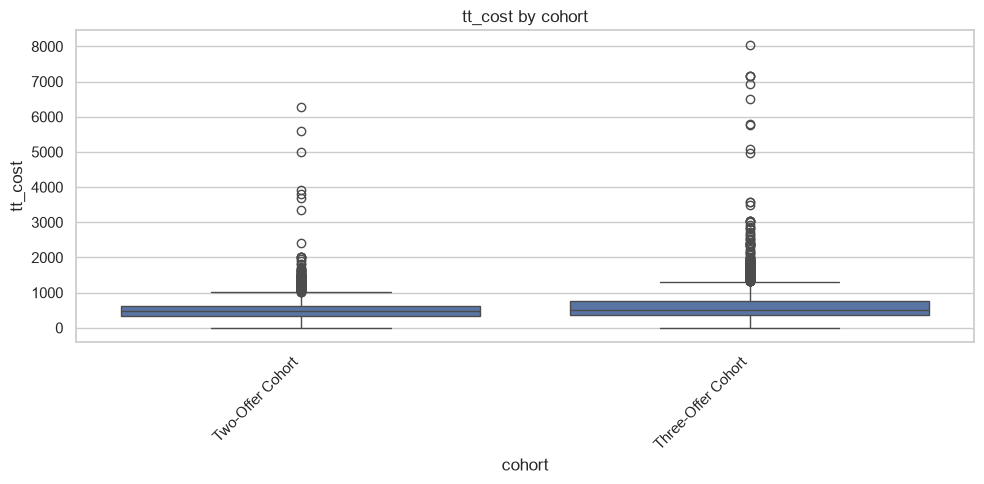

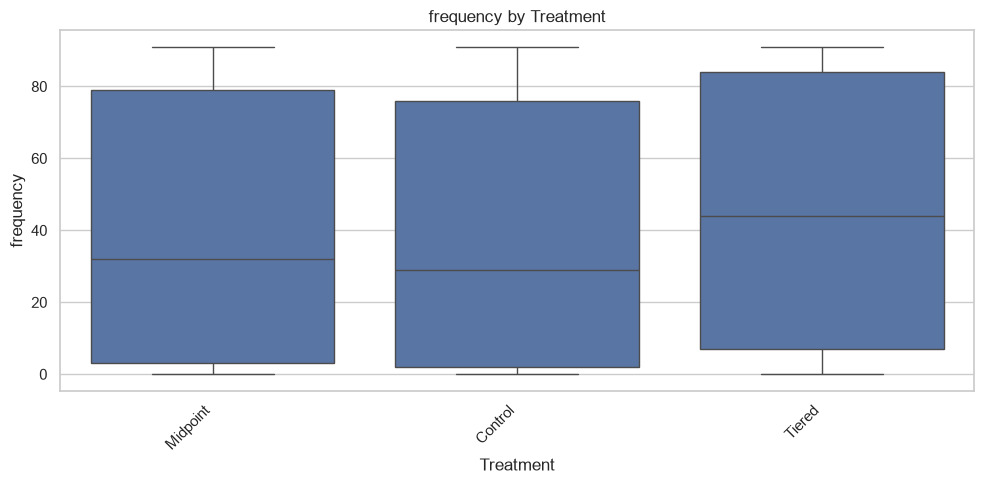

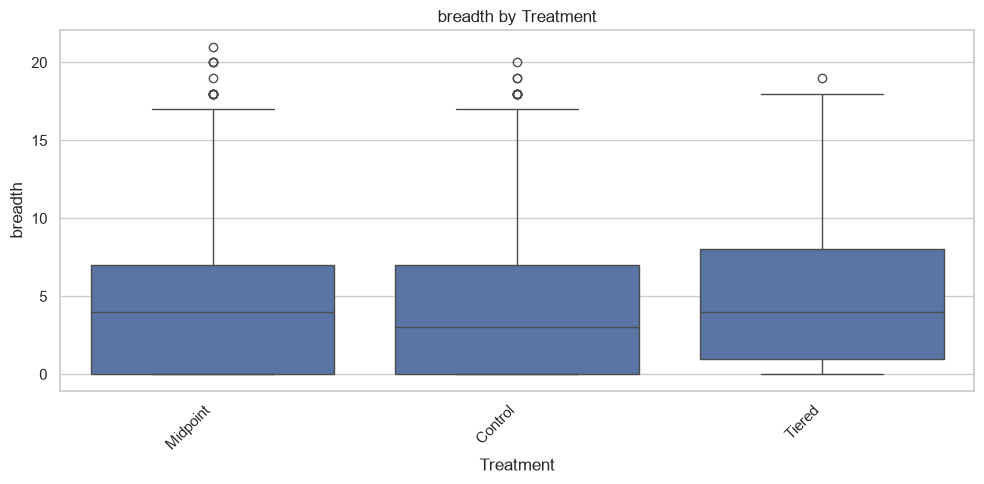

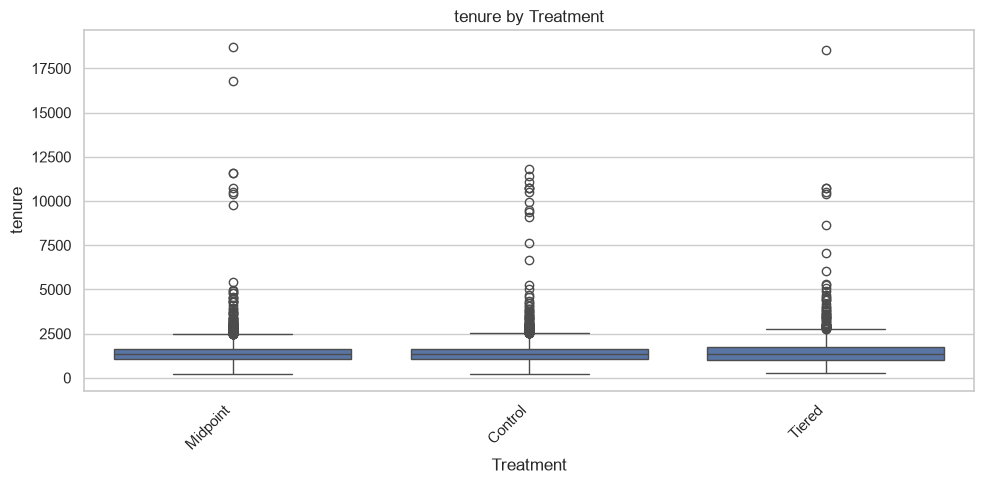

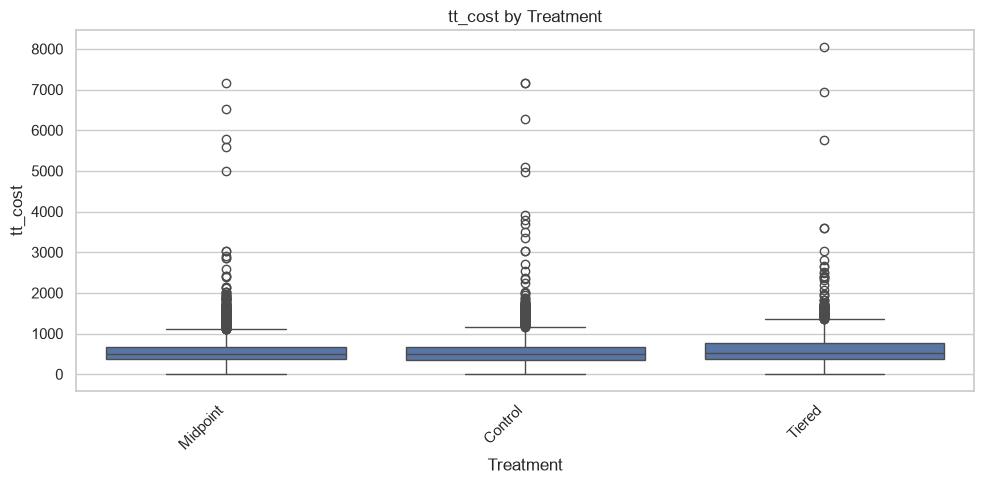

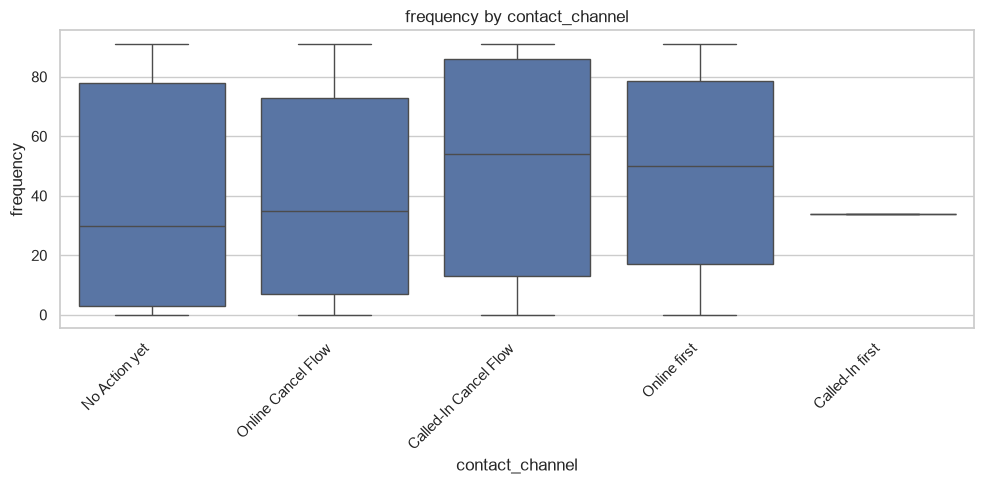

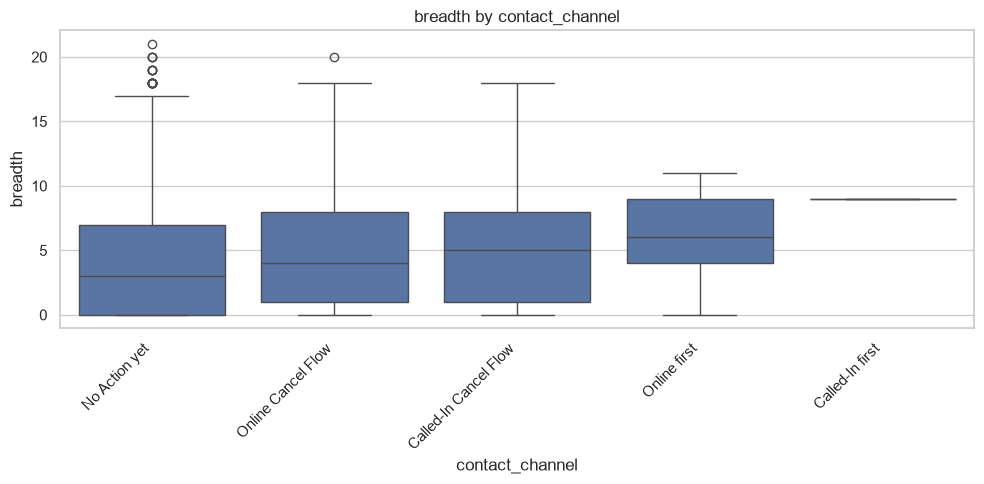

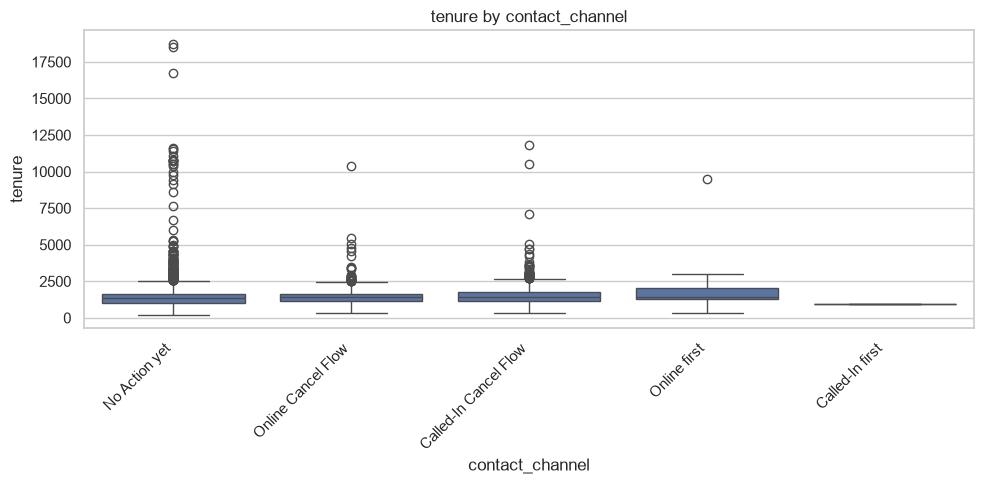

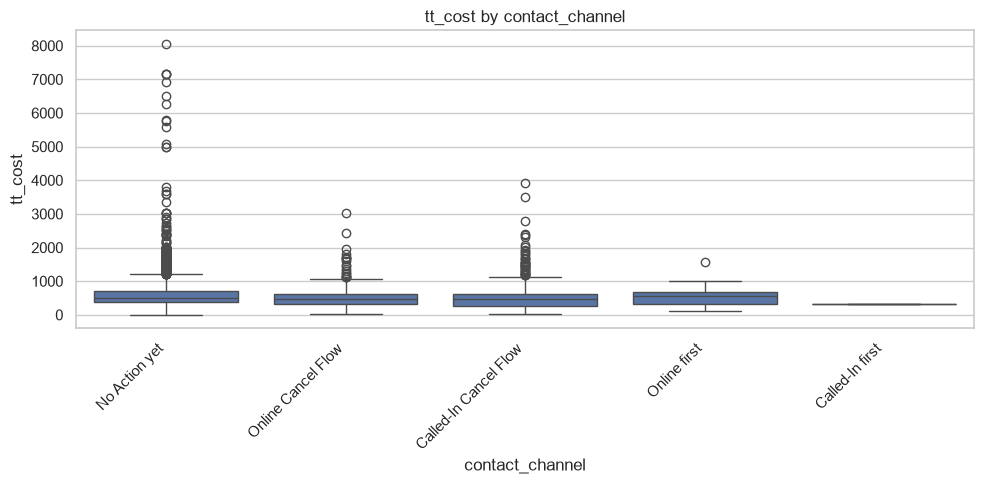

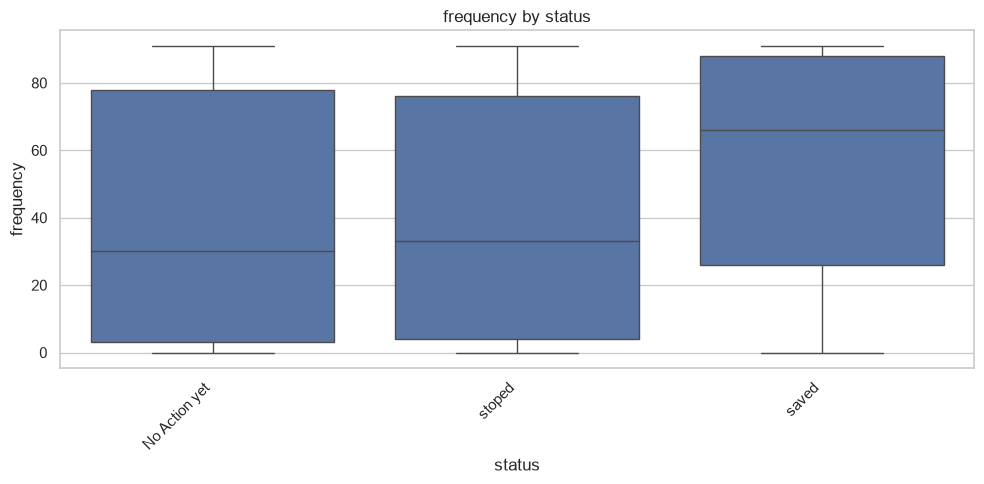

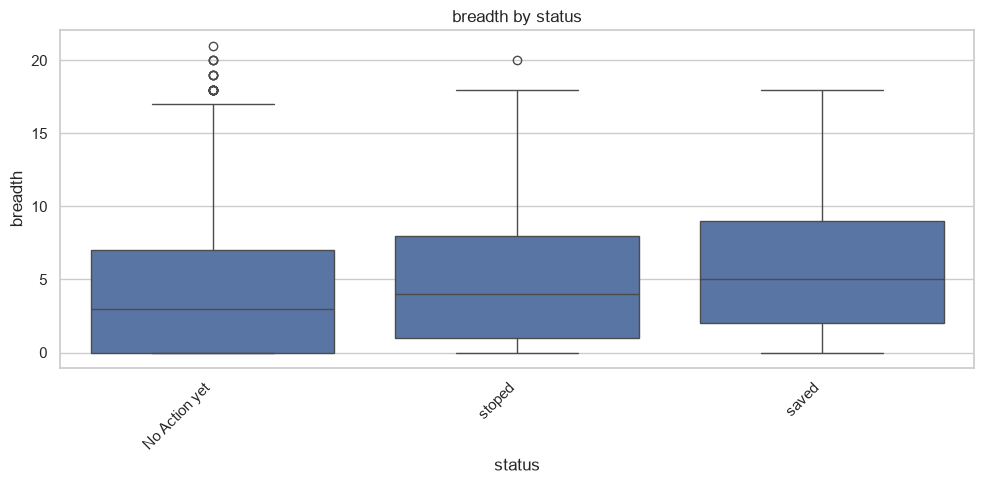

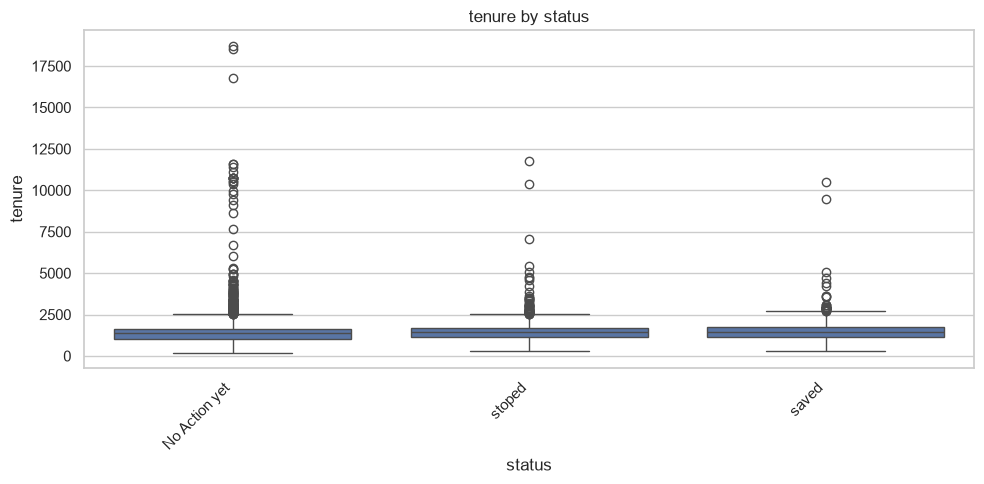

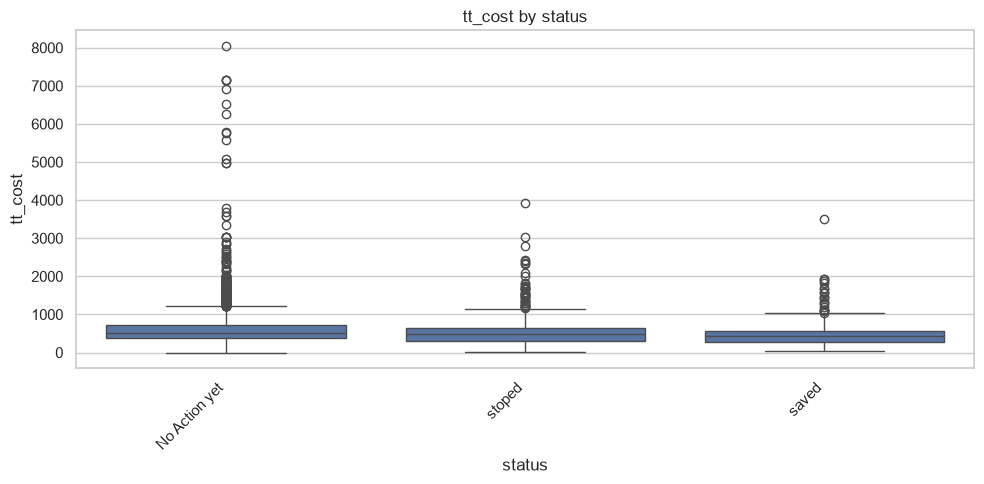

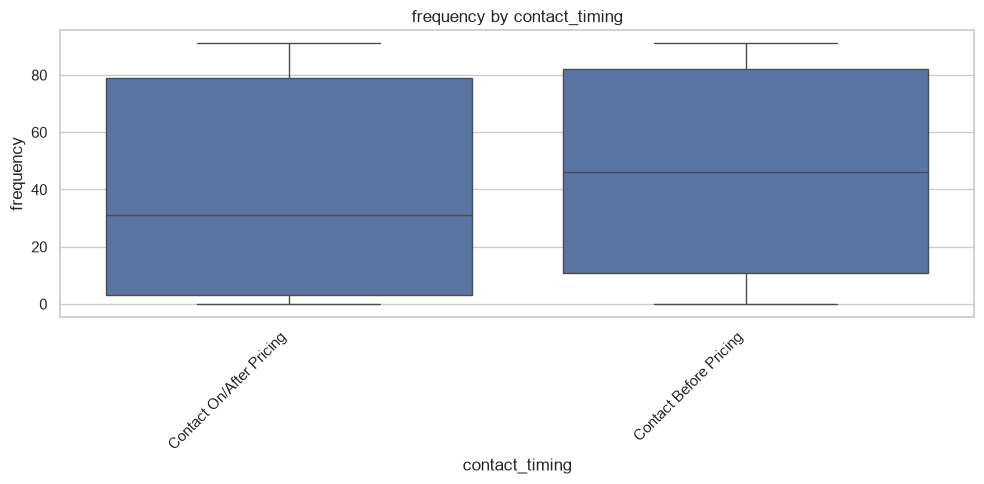

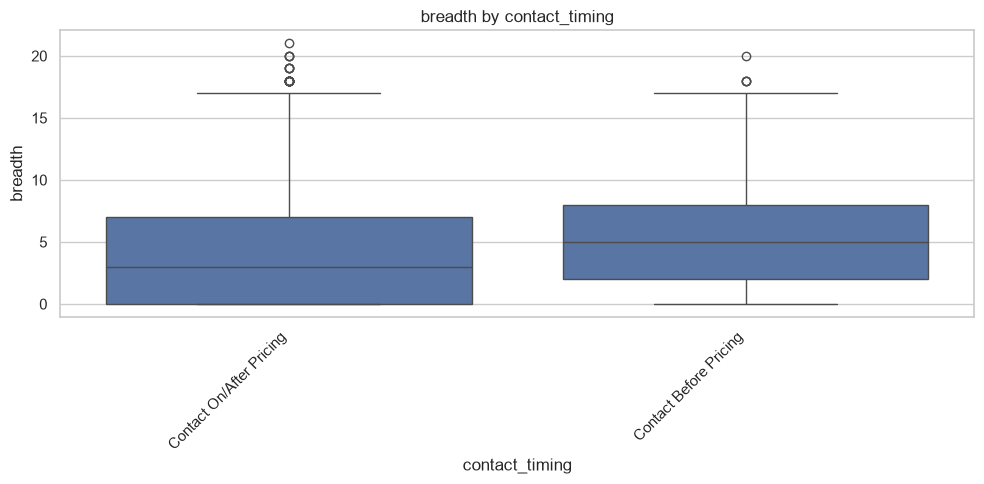

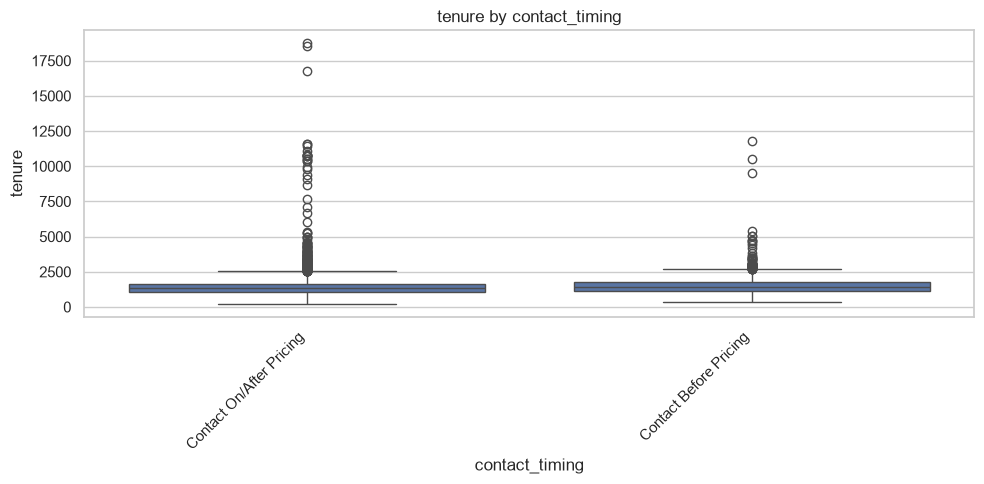

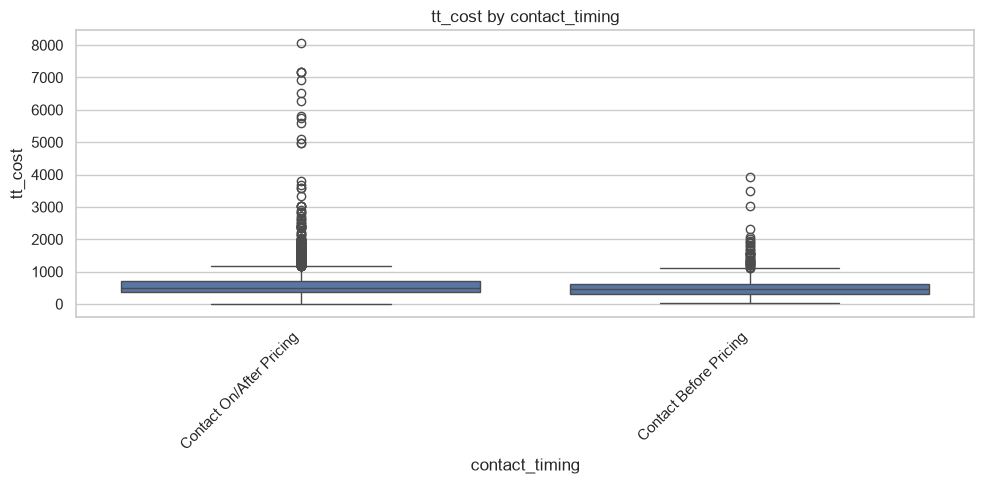

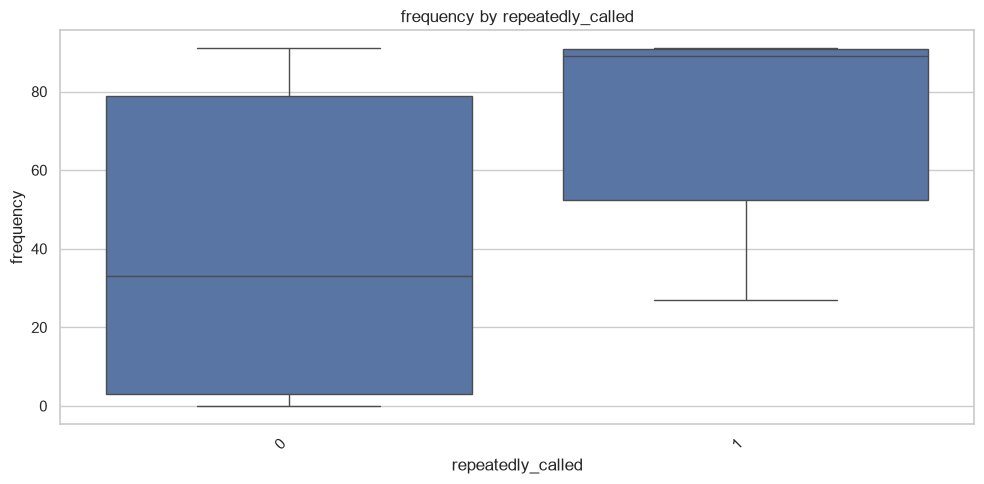

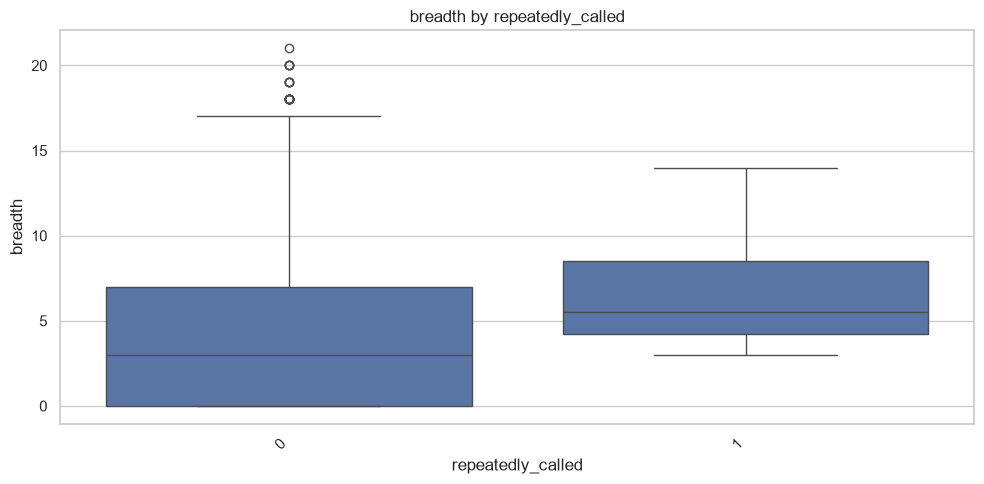

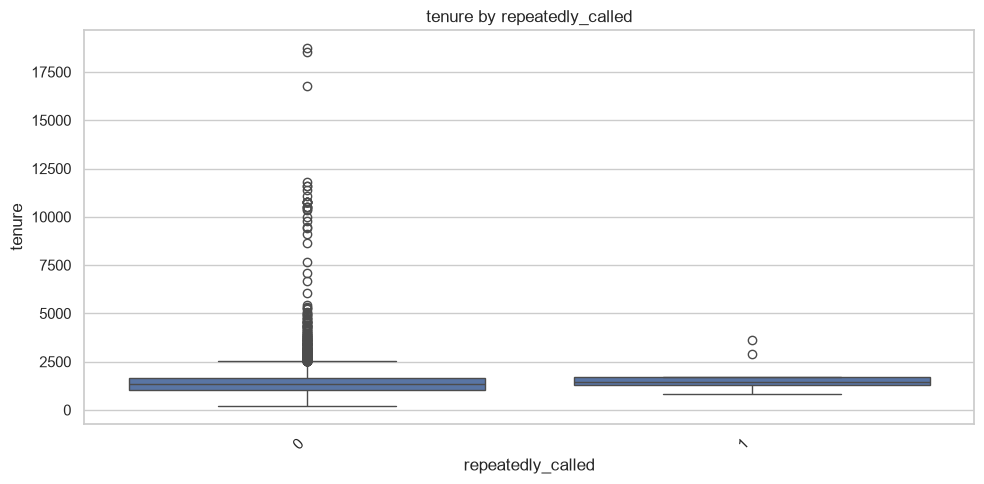

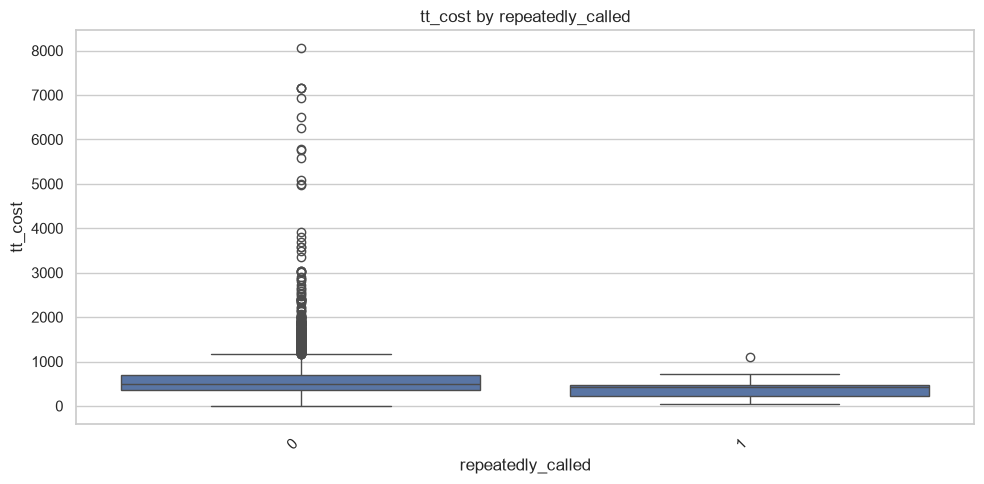

In [17]:
for segment in SEGMENT_FIELDS:
    if segment in df.columns:
        for metric in NUMERIC_FIELDS:
            top_segments = df[segment].value_counts().head(10).index

            plot_df = df[df[segment].isin(top_segments)]

            plt.figure(figsize=(10, 5))
            sns.boxplot(
                data=plot_df,
                x=segment,
                y=metric
            )
            plt.title(f"{metric} by {segment}")
            plt.xlabel(segment)
            plt.ylabel(metric)
            plt.xticks(rotation=45, ha="right")
            plt.tight_layout()
            plt.show()

# Business Boxplots

## No Action vs Had Action

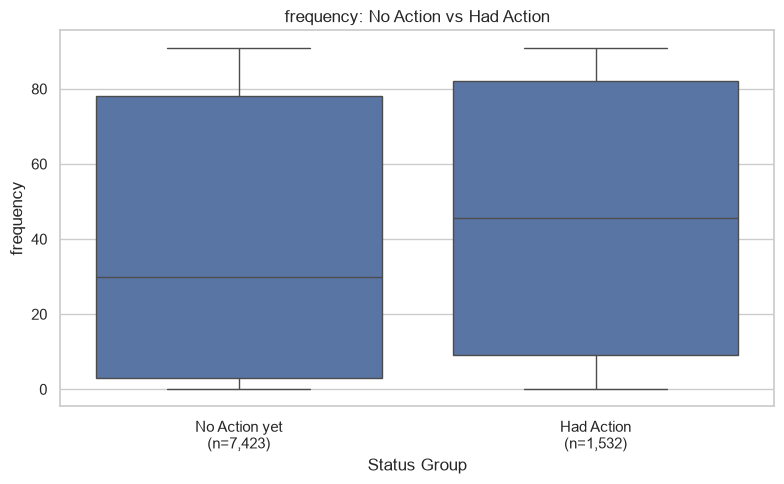

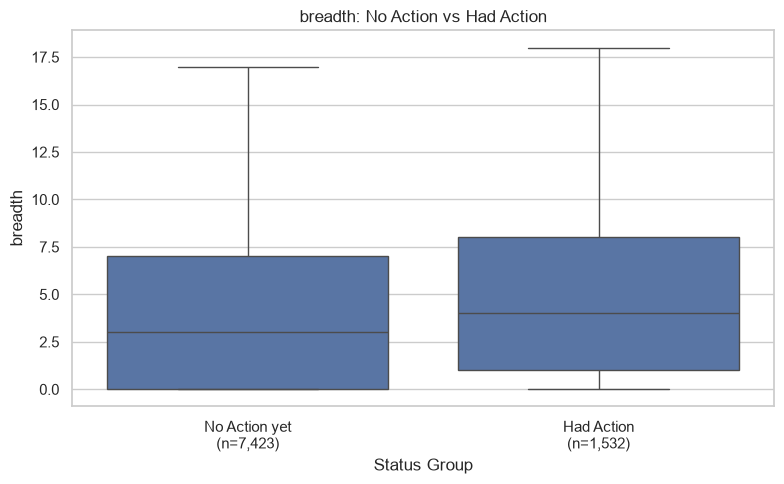

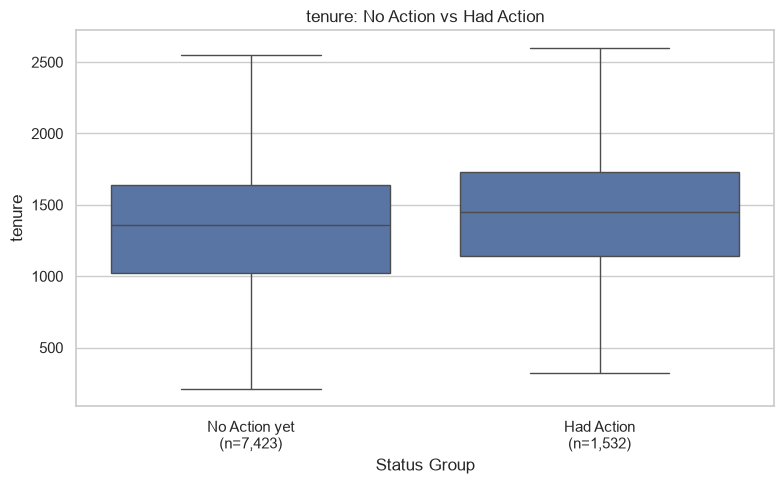

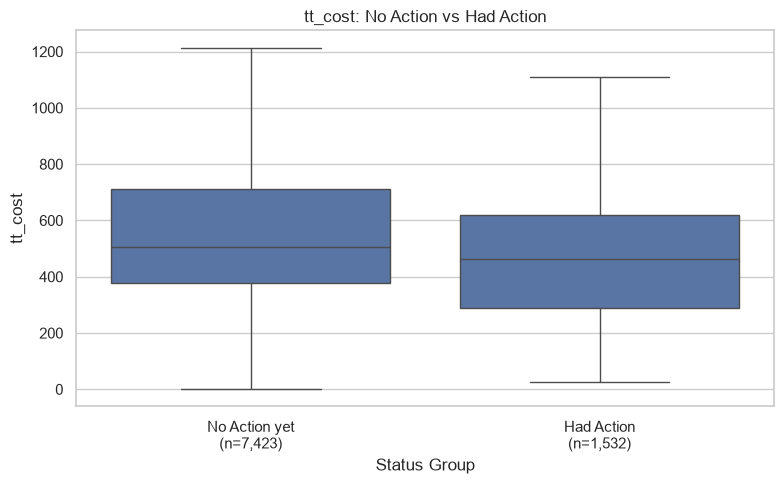

In [18]:
df["action_group"] = np.where(
    df["status"].eq("No Action yet"),
    "No Action yet",
    "Had Action"
)

action_order = ["No Action yet", "Had Action"]

for metric in NUMERIC_FIELDS:
    plot_df = df.dropna(subset=[metric, "action_group"]).copy()
    counts = plot_df.groupby("action_group")["billing_account"].count()
    order = [group for group in action_order if group in counts.index]

    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=plot_df,
        x="action_group",
        y=metric,
        order=order,
        showfliers=False
    )
    plt.xticks(
        range(len(order)),
        [f"{group}\n(n={counts.loc[group]:,})" for group in order]
    )
    plt.title(f"{metric}: No Action vs Had Action")
    plt.xlabel("Status Group")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

## Repeated Caller Among Had Action

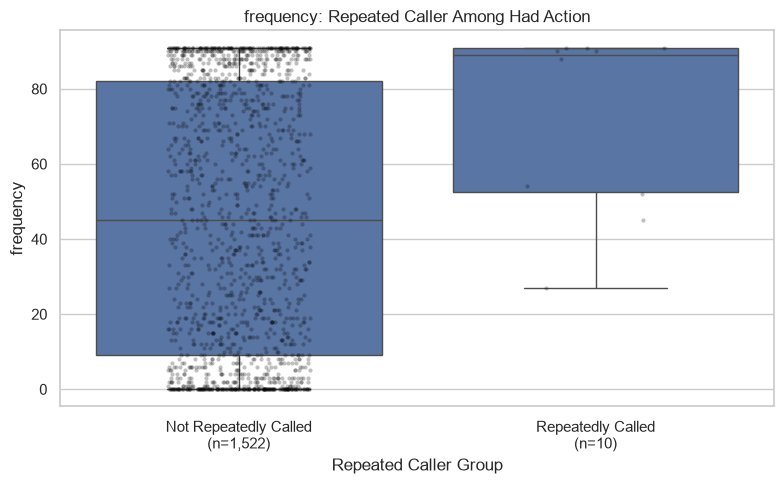

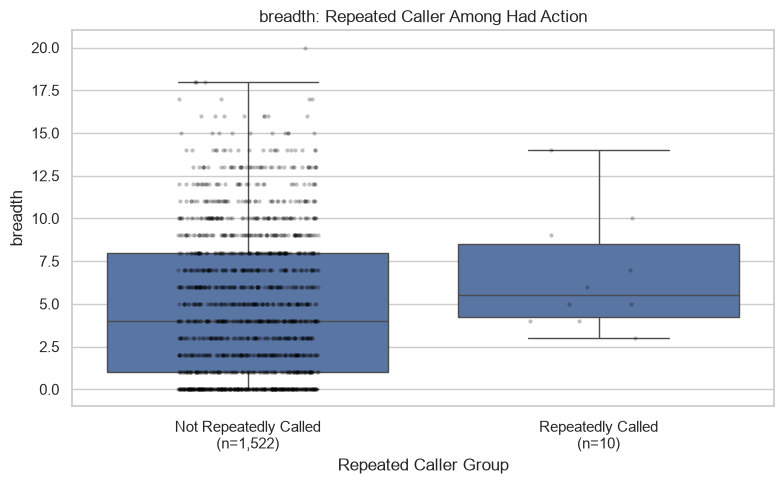

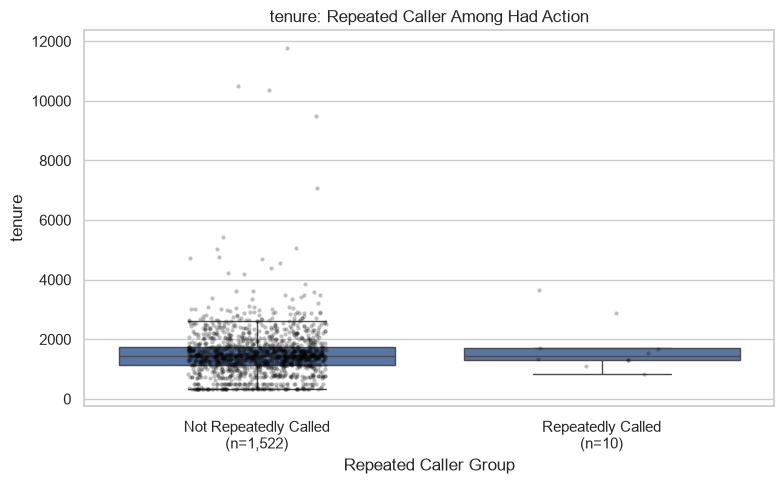

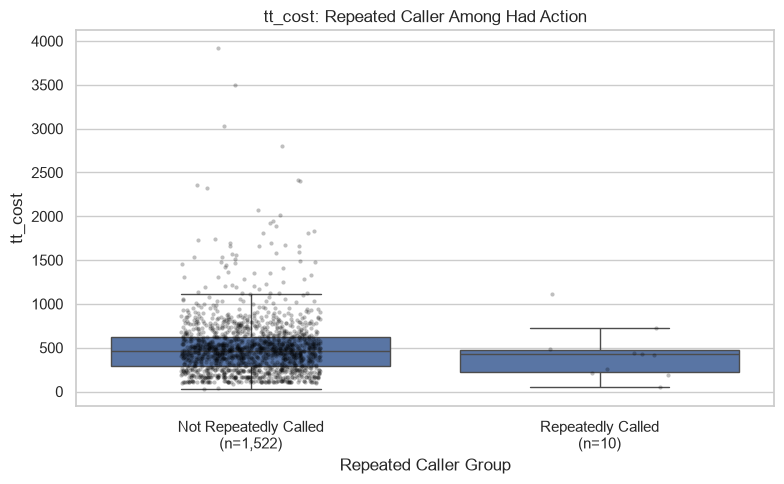

In [19]:
action_df = df[df["status"].ne("No Action yet")].copy()
action_df["repeated_call_group"] = np.where(
    action_df["repeatedly_called"].fillna(0).astype(int).eq(1),
    "Repeatedly Called",
    "Not Repeatedly Called"
)

repeated_call_order = ["Not Repeatedly Called", "Repeatedly Called"]

for metric in NUMERIC_FIELDS:
    plot_df = action_df.dropna(subset=[metric, "repeated_call_group"]).copy()
    counts = plot_df.groupby("repeated_call_group")["billing_account"].count()
    order = [group for group in repeated_call_order if group in counts.index]

    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=plot_df,
        x="repeated_call_group",
        y=metric,
        order=order,
        showfliers=False
    )
    sns.stripplot(
        data=plot_df,
        x="repeated_call_group",
        y=metric,
        order=order,
        color="black",
        alpha=0.25,
        size=3,
        jitter=0.2
    )
    plt.xticks(
        range(len(order)),
        [f"{group}\n(n={counts.loc[group]:,})" for group in order]
    )
    plt.title(f"{metric}: Repeated Caller Among Had Action")
    plt.xlabel("Repeated Caller Group")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

## Treatment Comparison Within Segment Slice

In [20]:
TREATMENT_ORDER = ["Control", "Midpoint", "Tiered"]
SLICE_FIELDS = ["contact_channel", "cohort", "src_risk_tier", "contact_timing"]

def plot_treatment_slice(
    metric,
    contact_channel=None,
    cohort=None,
    src_risk_tier=None,
    contact_timing=None,
    min_n=5,
):
    plot_df = df[df["status"].ne("No Action yet")].copy()

    filters = {
        "contact_channel": contact_channel,
        "cohort": cohort,
        "src_risk_tier": src_risk_tier,
        "contact_timing": contact_timing,
    }

    for col, value in filters.items():
        if value is not None:
            plot_df = plot_df[plot_df[col].eq(value)]

    plot_df = plot_df.dropna(subset=[metric, "Treatment"])
    counts = plot_df.groupby("Treatment")["billing_account"].count()
    valid_treatments = counts[counts >= min_n].index.tolist()

    plot_df = plot_df[plot_df["Treatment"].isin(valid_treatments)]

    if plot_df.empty:
        print("No treatment groups meet the minimum sample size.")
        display(counts.rename("users").reset_index().sort_values("users", ascending=False))
        return

    order = [treatment for treatment in TREATMENT_ORDER if treatment in valid_treatments]
    order += [treatment for treatment in valid_treatments if treatment not in order]

    plt.figure(figsize=(9, 5))
    sns.boxplot(
        data=plot_df,
        x="Treatment",
        y=metric,
        order=order,
        showfliers=False
    )
    sns.stripplot(
        data=plot_df,
        x="Treatment",
        y=metric,
        order=order,
        color="black",
        alpha=0.25,
        size=3,
        jitter=0.2
    )
    plt.xticks(
        range(len(order)),
        [f"{treatment}\n(n={counts.loc[treatment]:,})" for treatment in order]
    )
    title_filters = ", ".join(
        f"{col}={value}" for col, value in filters.items() if value is not None
    )
    plt.title(f"{metric} by Treatment | {title_filters}")
    plt.xlabel("Treatment")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

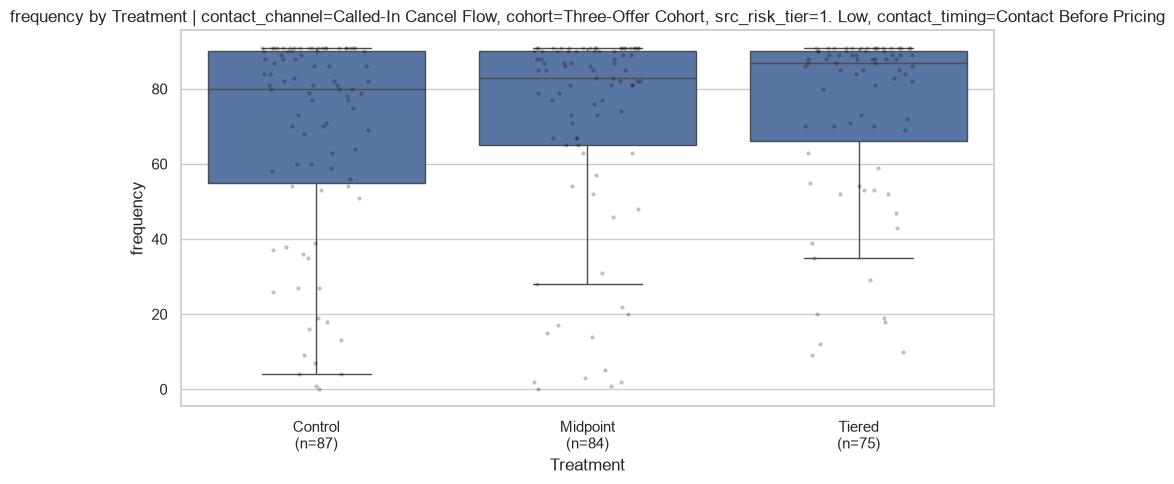

In [21]:
plot_treatment_slice(
    metric="frequency",
    contact_channel="Called-In Cancel Flow",
    cohort="Three-Offer Cohort",
    src_risk_tier="1. Low",
    contact_timing="Contact Before Pricing",
    min_n=5,
)

## Available Segment Combinations

In [22]:
segment_combo_counts = (
    df[df["status"].ne("No Action yet")]
    .groupby(SLICE_FIELDS + ["Treatment"], dropna=False)
    .agg(users=("billing_account", "count"))
    .reset_index()
    .sort_values("users", ascending=False)
)

display(segment_combo_counts.head(50))

,contact_channel,cohort,src_risk_tier,contact_timing,Treatment,users
24,Called-In Cancel Flow,Two-Offer Cohort,NaN,Contact Before Pricing,Control,90
0,Called-In Cancel Flow,Three-Offer Cohort,1. Low,Contact Before Pricing,Control,87
25,Called-In Cancel Flow,Two-Offer Cohort,NaN,Contact Before Pricing,Midpoint,85
1,Called-In Cancel Flow,Three-Offer Cohort,1. Low,Contact Before Pricing,Midpoint,84
2,Called-In Cancel Flow,Three-Offer Cohort,1. Low,Contact Before Pricing,Tiered,75
54,Online Cancel Flow,Two-Offer Cohort,NaN,Contact Before Pricing,Midpoint,74
27,Called-In Cancel Flow,Two-Offer Cohort,NaN,Contact On/After Pricing,Midpoint,72
53,Online Cancel Flow,Two-Offer Cohort,NaN,Contact Before Pricing,Control,70
26,Called-In Cancel Flow,Two-Offer Cohort,NaN,Contact On/After Pricing,Control,57
4,Called-In Cancel Flow,Three-Offer Cohort,1. Low,Contact On/After Pricing,Midpoint,50


# WIP

In [23]:
# distribution_summary.to_csv("distribution_summary.csv")
# quality_df.to_csv("data_quality_summary.csv", index=False)
# outlier_df.to_csv("outlier_summary.csv", index=False)

# print("Saved summary files.")

In [24]:
# percentile_query = f"""
# SELECT
#   COUNT(*) AS row_count,

#   APPROX_QUANTILES(tenure, 100)[OFFSET(1)] AS tenure_p01,
#   APPROX_QUANTILES(tenure, 100)[OFFSET(25)] AS tenure_p25,
#   APPROX_QUANTILES(tenure, 100)[OFFSET(50)] AS tenure_p50,
#   APPROX_QUANTILES(tenure, 100)[OFFSET(75)] AS tenure_p75,
#   APPROX_QUANTILES(tenure, 100)[OFFSET(90)] AS tenure_p90,
#   APPROX_QUANTILES(tenure, 100)[OFFSET(95)] AS tenure_p95,
#   APPROX_QUANTILES(tenure, 100)[OFFSET(99)] AS tenure_p99,

#   APPROX_QUANTILES(total_cost, 100)[OFFSET(1)] AS total_cost_p01,
#   APPROX_QUANTILES(total_cost, 100)[OFFSET(25)] AS total_cost_p25,
#   APPROX_QUANTILES(total_cost, 100)[OFFSET(50)] AS total_cost_p50,
#   APPROX_QUANTILES(total_cost, 100)[OFFSET(75)] AS total_cost_p75,
#   APPROX_QUANTILES(total_cost, 100)[OFFSET(90)] AS total_cost_p90,
#   APPROX_QUANTILES(total_cost, 100)[OFFSET(95)] AS total_cost_p95,
#   APPROX_QUANTILES(total_cost, 100)[OFFSET(99)] AS total_cost_p99,

#   APPROX_QUANTILES(viewed_number_of_pages, 100)[OFFSET(1)] AS pages_p01,
#   APPROX_QUANTILES(viewed_number_of_pages, 100)[OFFSET(25)] AS pages_p25,
#   APPROX_QUANTILES(viewed_number_of_pages, 100)[OFFSET(50)] AS pages_p50,
#   APPROX_QUANTILES(viewed_number_of_pages, 100)[OFFSET(75)] AS pages_p75,
#   APPROX_QUANTILES(viewed_number_of_pages, 100)[OFFSET(90)] AS pages_p90,
#   APPROX_QUANTILES(viewed_number_of_pages, 100)[OFFSET(95)] AS pages_p95,
#   APPROX_QUANTILES(viewed_number_of_pages, 100)[OFFSET(99)] AS pages_p99

# FROM `{TABLE_ID}`
# """

# percentiles_bq = client.query(percentile_query).to_dataframe()
# percentiles_bq